# Analyse d'un portefeuille d'actions 📈

Petit projet perso : je récupère un historique de prix de 4 actions et je regarde
la **performance** et le **risque** d'un portefeuille.
Tickers : Apple, Microsoft, LVMH (MC.PA) et Airbus (AIR.PA).

Ce que je veux sortir :
- les rendements et la volatilité de chaque action
- le ratio de Sharpe (rendement rapporté au risque)
- les corrélations entre actions
- la valeur d'un portefeuille pondéré dans le temps

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams["figure.figsize"] = (9, 4)

prix = pd.read_csv("prix_actions.csv", parse_dates=["Date"], index_col="Date")
prix.head()

,AAPL,MSFT,MC.PA,AIR.PA
Date,,,,
2024-01-01,186.18,378.86,723.42,138.95
2024-01-02,185.94,383.39,718.56,139.36
2024-01-03,187.46,377.21,712.67,137.87
2024-01-04,190.96,375.43,704.13,139.20
2024-01-05,190.50,380.89,704.67,138.22


## 1. Les rendements quotidiens

Le rendement d'un jour = (prix du jour / prix de la veille) - 1.
En pandas c'est juste `pct_change()`.

In [2]:
rdt = prix.pct_change().dropna()
rdt.head()

,AAPL,MSFT,MC.PA,AIR.PA
Date,,,,
2024-01-02,-0.001289,0.011957,-0.006718,0.002951
2024-01-03,0.008175,-0.016119,-0.008197,-0.010692
2024-01-04,0.018671,-0.004719,-0.011983,0.009647
2024-01-05,-0.002409,0.014543,0.000767,-0.007040
2024-01-08,-0.002415,-0.007194,-0.011523,0.002098


## 2. Rendement, volatilité et ratio de Sharpe (annualisés)

On annualise : le rendement moyen est composé sur 252 jours de bourse,
et la volatilité (l'écart-type) est multipliée par racine de 252.

Le **ratio de Sharpe** = (rendement annualisé - taux sans risque) / volatilité.
Je prends 2 % comme taux sans risque.

In [3]:
JOURS = 252
taux_sans_risque = 0.02

rdt_annuel = (1 + rdt.mean()) ** JOURS - 1
vol_annuelle = rdt.std() * np.sqrt(JOURS)
sharpe = (rdt_annuel - taux_sans_risque) / vol_annuelle

resume = pd.DataFrame({
    "Rendement annualisé": rdt_annuel,
    "Volatilité annualisée": vol_annuelle,
    "Sharpe": sharpe,
}).round(3)
resume.sort_values("Sharpe", ascending=False)

,Rendement annualisé,Volatilité annualisée,Sharpe
AIR.PA,0.840,0.193,4.239
MSFT,0.219,0.174,1.144
AAPL,0.087,0.185,0.363
MC.PA,-0.212,0.222,-1.044


Airbus ressort très bien sur la période, LVMH décroche (Sharpe négatif).
À garder en tête : c'est sur **une seule période**, ça ne préjuge pas du futur.

## 3. Les corrélations

Si deux actions sont très corrélées (proche de 1), les mettre ensemble
diversifie peu le portefeuille.

In [4]:
rdt.corr().round(2)

,AAPL,MSFT,MC.PA,AIR.PA
AAPL,1.00,0.02,0.10,0.01
MSFT,0.02,1.00,-0.10,0.01
MC.PA,0.10,-0.10,1.00,0.02
AIR.PA,0.01,0.01,0.02,1.00


## 4. Valorisation du portefeuille

Je teste une allocation simple : 30 % Apple, 30 % Microsoft, 20 % LVMH, 20 % Airbus.
Je pars d'une base 100 et je suis la valeur dans le temps.

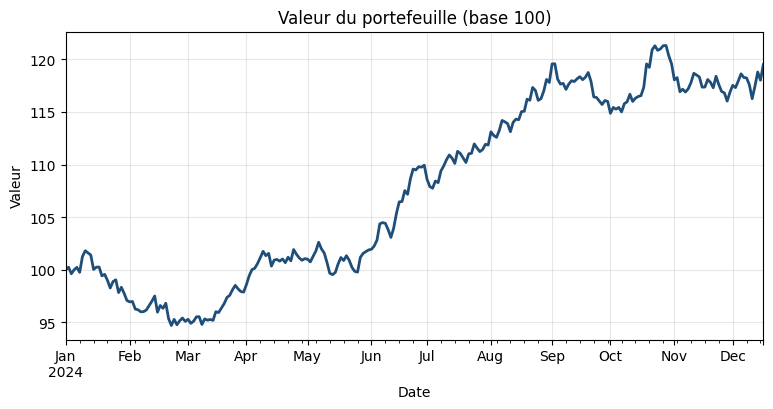

Valeur finale : 119.5  ->  +19.5 %


In [5]:
poids = {"AAPL": 0.30, "MSFT": 0.30, "MC.PA": 0.20, "AIR.PA": 0.20}

base = prix / prix.iloc[0]                       # tout ramené à 1 au départ
valo = (base * pd.Series(poids)).sum(axis=1) * 100

ax = valo.plot(color="#1f4e79", linewidth=2)
ax.set_title("Valeur du portefeuille (base 100)")
ax.set_ylabel("Valeur")
ax.grid(alpha=0.3)
plt.savefig("valorisation_portefeuille.png", dpi=110, bbox_inches="tight")
plt.show()

print(f"Valeur finale : {valo.iloc[-1]:.1f}  ->  {valo.iloc[-1]-100:+.1f} %")

## Conclusion

Sur la période, le portefeuille fait **+19,5 %**. Airbus tire la performance,
LVMH pèse un peu. Les corrélations entre actions sont faibles, donc la
diversification joue bien son rôle.

Prochaines idées : tester d'autres pondérations, ajouter un calcul de
max drawdown, et comparer à un indice de référence.